# MLP feedforward

In [1]:
# === Cell 0: imports & config ===

from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from scripts import style
style.mpl_apply()

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 246
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# Load the data

In [2]:
# === Cell 1: load df ===

DATA_PATH = Path("09 features/redes_local/datos/processed/df.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (200, 57)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,pct_bright_block_2_2,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label
0,102.20103,105.277170,106.873116,32.077003,33.305286,33.510914,0.0,0.0,0.0,186.0,...,0.195138,-1419.565426,1.198618,1.749636,0.486834,-0.154286,Alfred_Sisley_1.jpg,Alfred_Sisley,Impresionismo,4
1,123.62030,136.959850,149.195050,46.771084,43.979904,49.263435,0.0,0.0,0.0,255.0,...,0.098290,-1419.565426,1.061136,0.937835,0.502996,-0.188640,Alfred_Sisley_10.jpg,Alfred_Sisley,Impresionismo,4
2,118.90262,116.895996,108.091415,48.649280,52.237015,61.140570,0.0,0.0,0.0,255.0,...,0.117654,-1419.489874,0.852622,1.311007,0.504956,-0.304950,Alfred_Sisley_11.jpg,Alfred_Sisley,Impresionismo,4
3,133.78065,140.773590,146.314380,36.072636,36.483162,50.136950,4.0,4.0,0.0,255.0,...,0.018207,-1419.565426,1.091522,1.702214,0.500399,-0.215292,Alfred_Sisley_12.jpg,Alfred_Sisley,Impresionismo,4
4,107.30281,108.520706,92.723560,32.748276,32.094944,37.935650,0.0,0.0,0.0,229.0,...,0.020639,-1419.565426,1.132043,2.128325,0.506062,-0.137083,Alfred_Sisley_13.jpg,Alfred_Sisley,Impresionismo,4


In [3]:
# === Cell 2: encode painter and label meta ===

# Encode painters
painter_names = sorted(df["painter"].unique())
painter_to_idx = {name: i for i, name in enumerate(painter_names)}
idx_to_painter = {i: name for name, i in painter_to_idx.items()}

df["painter_idx"] = df["painter"].map(painter_to_idx)

NUM_PAINTERS = len(painter_names)

# Labels (movement / genre index)
# Assume df["label"] is already integer-coded per genre
NUM_LABELS = df["label"].nunique()

# Derive genre names per label (sorted by label index)
label_to_genre = (
    df.drop_duplicates("label")
      .sort_values("label")
      .set_index("label")["genre"]
      .to_dict()
)
class_names = [label_to_genre[i] for i in range(NUM_LABELS)]

print("Painters:", painter_names)
print("NUM_PAINTERS:", NUM_PAINTERS)
print("NUM_LABELS:", NUM_LABELS)
print("Labels → genres:", label_to_genre)


Painters: ['Alfred_Sisley', 'Camille_Pissarro', 'Caravaggio', 'Claude_Monet', 'Jackson_Pollock', 'Joan_Miro', 'Pablo_Picasso', 'Rembrandt', 'Rene_Magritte', 'Salvador_Dali', 'Vincent_van_Gogh']
NUM_PAINTERS: 11
NUM_LABELS: 5
Labels → genres: {0: 'Surrealismo', 1: 'Cubismo', 2: 'Expresionismo abstracto', 3: 'Barroco', 4: 'Impresionismo'}


In [4]:
# === Cell 3: build feature matrix and targets ===

meta_cols = ["filename", "painter", "genre", "label", "painter_idx"]

feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].to_numpy(dtype=np.float32)
y_painter = df["painter_idx"].to_numpy(dtype=np.int64)
y_label   = df["label"].to_numpy(dtype=np.int64)

print("X shape:", X.shape)
print("y_painter shape:", y_painter.shape)
print("y_label shape:", y_label.shape)
print("Painter counts:", np.bincount(y_painter))
print("Label counts:",   np.bincount(y_label))


X shape: (200, 53)
y_painter shape: (200,)
y_label shape: (200,)
Painter counts: [20 10 10 30 15 20 30 20 10 20 15]
Label counts: [50 30 15 30 75]


# Train test

In [5]:
# === Cell 4: train / validation split (no test split here) ===

X_train, X_val, y_p_train, y_p_val, y_l_train, y_l_val = train_test_split(
    X,
    y_painter,
    y_label,
    test_size=0.1,           # e.g. 80% train / 20% val
    stratify=y_painter,      # stratify by painter (since painter is first task)
    random_state=SEED,
)

print("Train X:", X_train.shape)
print("Val   X:", X_val.shape)


Train X: (180, 53)
Val   X: (20, 53)


In [6]:
X_train

array([[ 3.89606476e+01,  3.09182320e+01,  2.29869804e+01, ...,
         1.20499253e+00,  5.53446591e-01, -1.64675206e-01],
       [ 1.90736710e+02,  1.65083496e+02,  1.44668900e+02, ...,
         1.09038329e+00,  5.08438170e-01, -1.49979129e-01],
       [ 1.70989334e+02,  1.73403061e+02,  1.68097824e+02, ...,
         1.32370436e+00,  5.23522198e-01, -8.47036317e-02],
       ...,
       [ 1.66685593e+02,  1.56943695e+02,  1.21151726e+02, ...,
         3.27272676e-02,  4.71966326e-01, -1.03057981e-01],
       [ 1.32588089e+02,  1.20604446e+02,  1.21858635e+02, ...,
         9.87241685e-01,  4.96049196e-01, -1.61776572e-01],
       [ 4.39953804e+01,  3.48429832e+01,  3.28558578e+01, ...,
         5.21066904e+00,  4.75666314e-01, -2.11538091e-01]], dtype=float32)

In [7]:
# === Cell 5: scaling ===

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


# PyTorch

In [8]:
# === Cell 6: tensors & dataloaders (multi-target) ===

BATCH_SIZE = 32

X_train_t = torch.from_numpy(X_train_scaled).float()
y_p_train_t = torch.from_numpy(y_p_train).long()
y_l_train_t = torch.from_numpy(y_l_train).long()

X_val_t = torch.from_numpy(X_val_scaled).float()
y_p_val_t = torch.from_numpy(y_p_val).long()
y_l_val_t = torch.from_numpy(y_l_val).long()

train_ds = TensorDataset(X_train_t, y_p_train_t, y_l_train_t)
val_ds   = TensorDataset(X_val_t,   y_p_val_t,   y_l_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader)


(6, 1)

In [9]:
# === Cell 7: class weights for imbalance ===

# Painter weights
painter_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_PAINTERS),
    y=y_p_train,
)

# Label weights (genre / movement)
label_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=y_l_train,
)

print("Painter class weights:", painter_class_weights)
print("Label   class weights:", label_class_weights)

painter_class_weights_t = torch.tensor(painter_class_weights, dtype=torch.float32, device=device)
label_class_weights_t   = torch.tensor(label_class_weights,   dtype=torch.float32, device=device)


Painter class weights: [0.90909091 1.81818182 1.81818182 0.60606061 1.25874126 0.90909091
 0.60606061 0.90909091 1.81818182 0.90909091 1.16883117]
Label   class weights: [0.8        1.33333333 2.76923077 1.33333333 0.52941176]


# Training

In [10]:
# === Cell 8: multi-task MLP definition ===

class MultiTaskMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims=(128, 64),
        num_painters: int = NUM_PAINTERS,
        num_labels: int = NUM_LABELS,
        dropout_p: float = 0.3,
    ):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev_dim = h

        self.shared = nn.Sequential(*layers)
        self.painter_head = nn.Linear(prev_dim, num_painters)
        self.label_head   = nn.Linear(prev_dim, num_labels)

    def forward(self, x: torch.Tensor):
        z = self.shared(x)
        painter_logits = self.painter_head(z)
        label_logits   = self.label_head(z)
        return painter_logits, label_logits


## More dropout

In [11]:
import torch.nn as nn

class MultiTaskMLP_Slim(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        bottleneck: int = 16,     # strong bottleneck
        hidden_first: int = 32,
        dropout_p: float = 0.5,
    ):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.BatchNorm1d(hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_first, bottleneck),
            nn.Tanh(),             # squash → smaller effective range
            nn.Dropout(dropout_p),
        )

        self.painter_head = nn.Linear(bottleneck, num_painters)
        self.label_head   = nn.Linear(bottleneck, num_labels)

    def forward(self, x: torch.Tensor):
        h = self.trunk(x)
        painter_logits = self.painter_head(h)
        label_logits   = self.label_head(h)
        return painter_logits, label_logits





## RBF

In [12]:
from sklearn.cluster import KMeans

N_RBF = 32    # number of RBF centers; keep small (10–40)
kmeans = KMeans(n_clusters=N_RBF, random_state=SEED)
kmeans.fit(X_train_scaled)   # shape (n_train, d)

centers = torch.from_numpy(kmeans.cluster_centers_).float().to(device)


c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [13]:
class RBFLayer(nn.Module):
    def __init__(self, centers: torch.Tensor, gamma: float = 1.0):
        """
        centers: (K, D) tensor (fixed)
        gamma: 1/(2*sigma^2); controls width of RBFs
        """
        super().__init__()
        self.centers = nn.Parameter(centers, requires_grad=False)
        self.gamma = nn.Parameter(torch.tensor(gamma, dtype=torch.float32), requires_grad=False)

    def forward(self, x: torch.Tensor):
        # x: (B, D), centers: (K, D)
        # Compute squared distances: (B, K)
        # ||x - c||^2 = (x^2).sum + (c^2).sum - 2 x·c
        x2 = (x ** 2).sum(dim=1, keepdim=True)              # (B, 1)
        c2 = (self.centers ** 2).sum(dim=1).unsqueeze(0)    # (1, K)
        xc = x @ self.centers.t()                           # (B, K)
        dist2 = x2 + c2 - 2 * xc
        # RBF activations
        phi = torch.exp(-self.gamma * dist2)
        return phi


In [14]:
class MultiTaskMLP_RBF(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        centers: torch.Tensor,
        hidden_first: int = 32,
        dropout_p: float = 0.4,
        gamma: float = 1.0,
    ):
        super().__init__()

        # Linear pre-transform to "RBF space"
        self.pre = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        self.rbf = RBFLayer(centers, gamma=gamma)  # output dim = N_RBF

        rbf_dim = centers.shape[0]

        self.painter_head = nn.Sequential(
            nn.Linear(rbf_dim, num_painters),
        )
        self.label_head   = nn.Sequential(
            nn.Linear(rbf_dim, num_labels),
        )

    def forward(self, x: torch.Tensor):
        h = self.pre(x)
        phi = self.rbf(h)
        painter_logits = self.painter_head(phi)
        label_logits   = self.label_head(phi)
        return painter_logits, label_logits


In [15]:
import torch
import torch.nn as nn

class RBFLayerLearnable(nn.Module):
    def __init__(self, in_dim: int, num_centers: int, init_gamma: float = 1.0):
        """
        in_dim:      dimensionality of the input to this RBF layer (e.g. hidden_first)
        num_centers: number of RBF units K
        init_gamma:  initial gamma; effective RBF is exp(-gamma * ||x - c||^2)
        """
        super().__init__()
        self.in_dim = in_dim
        self.num_centers = num_centers

        # Centers are learnable parameters: (K, D)
        self.centers = nn.Parameter(
            0.1 * torch.randn(num_centers, in_dim)  # small random init
        )

        # Learnable log-gamma so that gamma stays > 0
        self.log_gamma = nn.Parameter(
            torch.log(torch.tensor(init_gamma, dtype=torch.float32))
        )

    def forward(self, x: torch.Tensor):
        """
        x: (B, D) where D = in_dim
        returns: (B, K) RBF activations
        """
        # ensure gamma > 0
        gamma = torch.exp(self.log_gamma)

        # x^2: (B, 1)
        x2 = (x ** 2).sum(dim=1, keepdim=True)
        # c^2: (1, K)
        c2 = (self.centers ** 2).sum(dim=1).unsqueeze(0)
        # x·c: (B, K)
        xc = x @ self.centers.t()

        # squared distance: (B, K)
        dist2 = x2 + c2 - 2 * xc

        # RBF features: (B, K)
        phi = torch.exp(-gamma * dist2)
        return phi


## RBF Learnable

In [16]:
class MultiTaskMLP_RBF_Learnable(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        hidden_first: int = 32,
        n_rbf: int = 20,
        dropout_p: float = 0.4,
        init_gamma: float = 1.0,
    ):
        super().__init__()

        # Linear + ReLU pre-transform: R^d -> R^{hidden_first}
        self.pre = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        # RBF layer in this hidden space: centers ∈ R^{n_rbf × hidden_first}
        self.rbf = RBFLayerLearnable(
            in_dim=hidden_first,
            num_centers=n_rbf,
            init_gamma=init_gamma,
        )

        self.dropout = nn.Dropout(dropout_p)

        # Heads see K-dimensional RBF feature vector
        self.painter_head = nn.Linear(n_rbf, num_painters)
        self.label_head   = nn.Linear(n_rbf, num_labels)

    def forward(self, x: torch.Tensor):
        # x: (B, input_dim)
        h = self.pre(x)          # (B, hidden_first)
        phi = self.rbf(h)        # (B, n_rbf)
        phi = self.dropout(phi)  # optional extra regularization

        painter_logits = self.painter_head(phi)  # (B, num_painters)
        label_logits   = self.label_head(phi)    # (B, num_labels)
        return painter_logits, label_logits


In [17]:
input_dim = X_train.shape[1]  # same as before



In [18]:
iwant = "slim"
input_dim = X_train.shape[1]
if iwant == "base":
    # usage:
    model = MultiTaskMLP(
        input_dim=input_dim,
        hidden_dims=(64, 32),
        num_painters=NUM_PAINTERS,
        num_labels=NUM_LABELS,
        dropout_p=0.3,
    )
    model.to(device)
elif iwant == "slim":
    # usage:
    model = MultiTaskMLP_Slim(
        input_dim=input_dim,
        num_painters=NUM_PAINTERS,
        num_labels=NUM_LABELS,
        bottleneck=16,
        hidden_first=32,
        dropout_p=0.5,
    ).to(device)
elif iwant == "rbf":
    # usage:
    model = MultiTaskMLP_RBF(
        input_dim=input_dim,
        num_painters=NUM_PAINTERS,
        num_labels=NUM_LABELS,
        centers=centers,
        hidden_first=32,
        dropout_p=0.4,
        gamma=1.0,   # tune gamma between e.g. 0.1 and 5.0
    ).to(device)
elif iwant == "rbf_learnable":
    model = MultiTaskMLP_RBF_Learnable(
    input_dim=input_dim,
    num_painters=NUM_PAINTERS,
    num_labels=NUM_LABELS,
    hidden_first=32,   # or 16 / 64, etc.
    n_rbf=20,          # number of RBF units (capacity knob)
    dropout_p=0.4,
    init_gamma=1.0,
    ).to(device)

model

MultiTaskMLP_Slim(
  (trunk): Sequential(
    (0): Linear(in_features=53, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Dropout(p=0.5, inplace=False)
  )
  (painter_head): Linear(in_features=16, out_features=11, bias=True)
  (label_head): Linear(in_features=16, out_features=5, bias=True)
)

In [19]:
# === Cell 9: helpers for train & eval (multi-task) ===

def train_one_epoch(
    model,
    loader,
    optimizer,
    painter_criterion,
    label_criterion,
    device,
    lambda_p: float = 1.0,
    lambda_l: float = 1.0,
):
    model.train()
    total = 0
    sum_loss = 0.0
    correct_painter = 0
    correct_label = 0

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)
        y_l_batch = y_l_batch.to(device)

        optimizer.zero_grad()
        painter_logits, label_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)
        label_loss   = label_criterion(label_logits,   y_l_batch)

        loss = lambda_p * painter_loss + lambda_l * label_loss
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        sum_loss += loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        label_pred   = label_logits.argmax(dim=1)

        correct_painter += (painter_pred == y_p_batch).sum().item()
        correct_label   += (label_pred   == y_l_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    label_acc   = correct_label   / total
    return epoch_loss, painter_acc, label_acc


@torch.no_grad()
def evaluate(
    model,
    loader,
    painter_criterion,
    label_criterion,
    device,
    lambda_p: float = 1.0,
    lambda_l: float = 1.0,
):
    model.eval()
    total = 0
    sum_loss = 0.0
    correct_painter = 0
    correct_label = 0

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)
        y_l_batch = y_l_batch.to(device)

        painter_logits, label_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)
        label_loss   = label_criterion(label_logits,   y_l_batch)

        loss = lambda_p * painter_loss + lambda_l * label_loss

        batch_size = X_batch.size(0)
        sum_loss += loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        label_pred   = label_logits.argmax(dim=1)

        correct_painter += (painter_pred == y_p_batch).sum().item()
        correct_label   += (label_pred   == y_l_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    label_acc   = correct_label   / total
    return epoch_loss, painter_acc, label_acc


In [20]:
# === Cell 10: training loop (multi-task) ===

EPOCHS = 1000
LR = 1e-3
WEIGHT_DECAY = 1e-4

painter_criterion = nn.CrossEntropyLoss(weight=painter_class_weights_t)
label_criterion   = nn.CrossEntropyLoss(weight=label_class_weights_t)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

LAMBDA_P = 1.0   # weight for painter loss
LAMBDA_L = 1.0   # weight for label loss

history = {
    "train_loss": [],
    "train_painter_acc": [],
    "train_label_acc": [],
    "val_loss": [],
    "val_painter_acc": [],
    "val_label_acc": [],
}

best_val_score = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_p_acc, train_l_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        painter_criterion,
        label_criterion,
        device,
        lambda_p=LAMBDA_P,
        lambda_l=LAMBDA_L,
    )

    val_loss, val_p_acc, val_l_acc = evaluate(
        model,
        val_loader,
        painter_criterion,
        label_criterion,
        device,
        lambda_p=LAMBDA_P,
        lambda_l=LAMBDA_L,
    )

    history["train_loss"].append(train_loss)
    history["train_painter_acc"].append(train_p_acc)
    history["train_label_acc"].append(train_l_acc)
    history["val_loss"].append(val_loss)
    history["val_painter_acc"].append(val_p_acc)
    history["val_label_acc"].append(val_l_acc)

    # Use sum of accuracies as selection score (or choose one)
    val_score = 0.5 * (val_p_acc + val_l_acc)

    if val_score > best_val_score:
        best_val_score = val_score
        best_state = model.state_dict()

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_p={train_p_acc:.3f}, train_l={train_l_acc:.3f} | "
        f"val_loss={val_loss:.4f}, val_p={val_p_acc:.3f}, val_l={val_l_acc:.3f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 01/1000 | train_loss=4.1835, train_p=0.117, train_l=0.144 | val_loss=4.0699, val_p=0.050, val_l=0.100
Epoch 02/1000 | train_loss=4.1298, train_p=0.078, train_l=0.144 | val_loss=4.0308, val_p=0.100, val_l=0.150
Epoch 03/1000 | train_loss=4.0243, train_p=0.117, train_l=0.172 | val_loss=3.9839, val_p=0.050, val_l=0.200
Epoch 04/1000 | train_loss=3.9741, train_p=0.100, train_l=0.228 | val_loss=3.9377, val_p=0.050, val_l=0.300
Epoch 05/1000 | train_loss=3.9781, train_p=0.089, train_l=0.194 | val_loss=3.8912, val_p=0.050, val_l=0.300
Epoch 06/1000 | train_loss=3.9569, train_p=0.106, train_l=0.206 | val_loss=3.8464, val_p=0.100, val_l=0.300
Epoch 07/1000 | train_loss=3.8807, train_p=0.150, train_l=0.300 | val_loss=3.8100, val_p=0.100, val_l=0.300
Epoch 08/1000 | train_loss=3.8698, train_p=0.122, train_l=0.267 | val_loss=3.7758, val_p=0.150, val_l=0.350
Epoch 09/1000 | train_loss=3.8294, train_p=0.161, train_l=0.300 | val_loss=3.7360, val_p=0.150, val_l=0.400
Epoch 10/1000 | train_loss=3

# Visualization

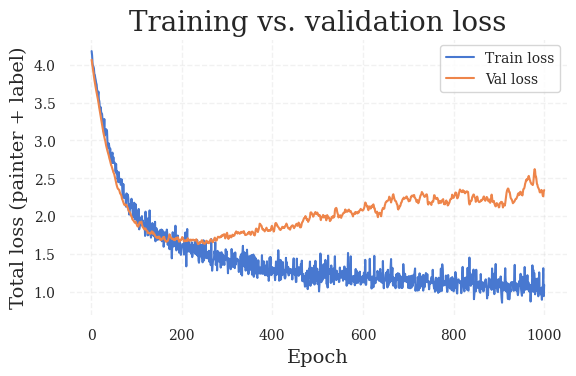

In [21]:
# === Cell 11: loss curves ===

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Total loss (painter + label)")
plt.title("Training vs. validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# === Cell 14: prediction helper for a loader ===

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_y_p = []
    all_y_l = []
    all_p_logits = []
    all_l_logits = []

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        p_logits, l_logits = model(X_batch)

        all_y_p.append(y_p_batch)
        all_y_l.append(y_l_batch)
        all_p_logits.append(p_logits.cpu())
        all_l_logits.append(l_logits.cpu())

    y_p_true = torch.cat(all_y_p).numpy()
    y_l_true = torch.cat(all_y_l).numpy()
    p_logits = torch.cat(all_p_logits)
    l_logits = torch.cat(all_l_logits)

    y_p_pred = p_logits.argmax(dim=1).numpy()
    y_l_pred = l_logits.argmax(dim=1).numpy()

    return y_p_true, y_l_true, y_p_pred, y_l_pred


## Painter

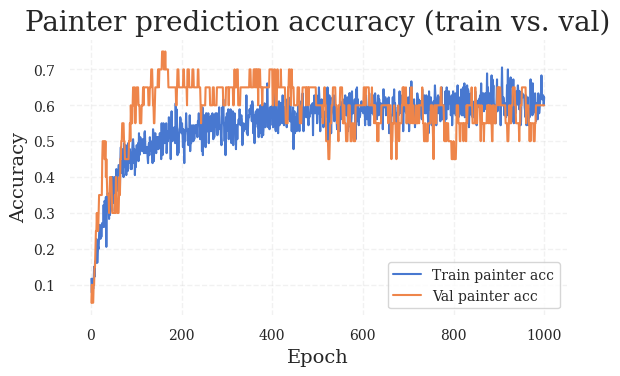

In [23]:
# === Cell 12: painter accuracy curves ===

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_painter_acc"], label="Train painter acc")
plt.plot(epochs, history["val_painter_acc"],   label="Val painter acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Painter prediction accuracy (train vs. val)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
# === Cell 15: metrics on validation set ===

y_p_true, y_l_true, y_p_pred, y_l_pred = predict_loader(model, val_loader, device)

# Painters
painter_acc = accuracy_score(y_p_true, y_p_pred)
print(f"Val painter accuracy: {painter_acc:.3f}")
print("\nPainter classification report (val):")
print(classification_report(y_p_true, y_p_pred, target_names=painter_names, digits=3))

Val painter accuracy: 0.600

Painter classification report (val):
                  precision    recall  f1-score   support

   Alfred_Sisley      0.000     0.000     0.000         2
Camille_Pissarro      0.000     0.000     0.000         1
      Caravaggio      0.500     1.000     0.667         1
    Claude_Monet      0.500     0.333     0.400         3
 Jackson_Pollock      1.000     1.000     1.000         2
       Joan_Miro      0.500     0.500     0.500         2
   Pablo_Picasso      0.500     0.333     0.400         3
       Rembrandt      1.000     1.000     1.000         2
   Rene_Magritte      1.000     1.000     1.000         1
   Salvador_Dali      0.667     1.000     0.800         2
Vincent_van_Gogh      0.333     1.000     0.500         1

        accuracy                          0.600        20
       macro avg      0.545     0.652     0.570        20
    weighted avg      0.558     0.600     0.558        20



c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


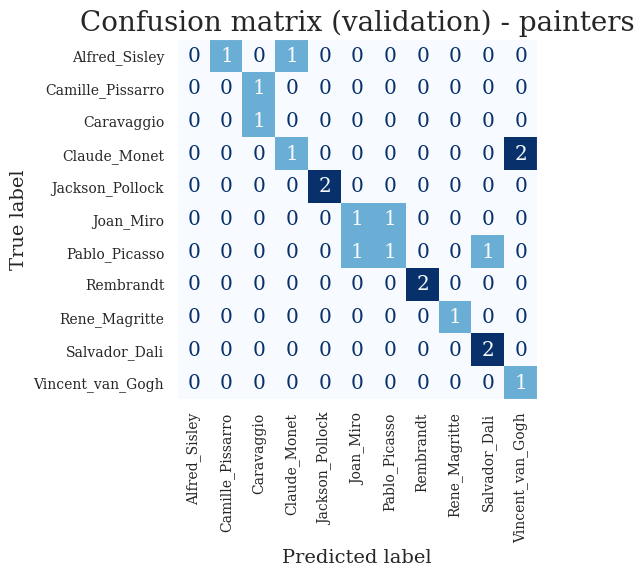

In [25]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_p_true, y_p_pred)

painter_names = sorted(df["painter"].unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=painter_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - painters")
plt.tight_layout()
plt.grid(False)
plt.show()


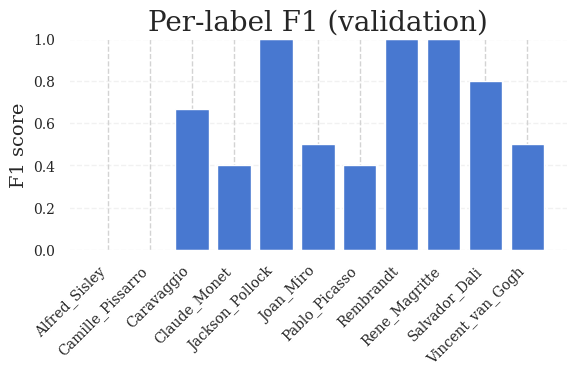

Alfred_Sisley                 : F1 = 0.000
Camille_Pissarro              : F1 = 0.000
Caravaggio                    : F1 = 0.667
Claude_Monet                  : F1 = 0.400
Jackson_Pollock               : F1 = 1.000
Joan_Miro                     : F1 = 0.500
Pablo_Picasso                 : F1 = 0.400
Rembrandt                     : F1 = 1.000
Rene_Magritte                 : F1 = 1.000
Salvador_Dali                 : F1 = 0.800
Vincent_van_Gogh              : F1 = 0.500


In [26]:
# === Cell 17: per-class F1 for labels ===

f1_per_painter = f1_score(
    y_p_true,
    y_p_pred,
    average=None,
    labels=np.arange(NUM_PAINTERS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_PAINTERS), f1_per_painter)
plt.xticks(range(NUM_PAINTERS), painter_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(painter_names, f1_per_painter):
    print(f"{name:30s}: F1 = {f1_val:.3f}")


## Genre

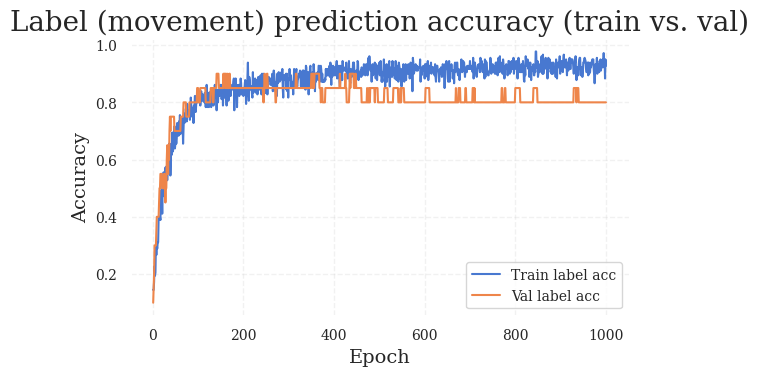

In [27]:
# === Cell 13: label accuracy curves ===

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_label_acc"], label="Train label acc")
plt.plot(epochs, history["val_label_acc"],   label="Val label acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Label (movement) prediction accuracy (train vs. val)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:

# Labels (genres)
label_acc = accuracy_score(y_l_true, y_l_pred)
print(f"\nVal label accuracy: {label_acc:.3f}")
print("\nLabel (genre) classification report (val):")
print(classification_report(y_l_true, y_l_pred, target_names=class_names, digits=3))



Val label accuracy: 0.800

Label (genre) classification report (val):
                         precision    recall  f1-score   support

            Surrealismo      0.667     0.800     0.727         5
                Cubismo      0.500     0.333     0.400         3
Expresionismo abstracto      1.000     1.000     1.000         2
                Barroco      0.750     1.000     0.857         3
          Impresionismo      1.000     0.857     0.923         7

               accuracy                          0.800        20
              macro avg      0.783     0.798     0.781        20
           weighted avg      0.804     0.800     0.793        20



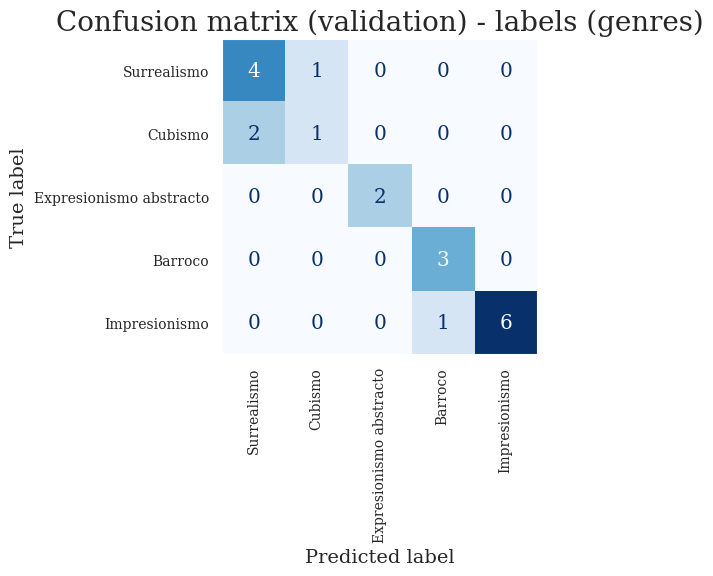

In [29]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_l_true, y_l_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - labels (genres)")
plt.tight_layout()
plt.grid(False)
plt.show()


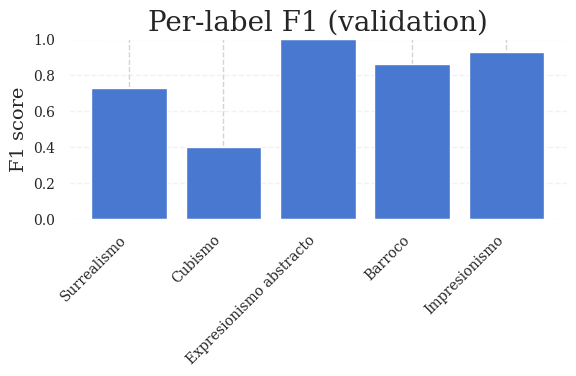

Surrealismo                   : F1 = 0.727
Cubismo                       : F1 = 0.400
Expresionismo abstracto       : F1 = 1.000
Barroco                       : F1 = 0.857
Impresionismo                 : F1 = 0.923


In [30]:
# === Cell 17: per-class F1 for labels ===

f1_per_label = f1_score(
    y_l_true,
    y_l_pred,
    average=None,
    labels=np.arange(NUM_LABELS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_LABELS), f1_per_label)
plt.xticks(range(NUM_LABELS), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(class_names, f1_per_label):
    print(f"{name:30s}: F1 = {f1_val:.3f}")


# Test

In [31]:
TEST_PATH = Path("09 features/redes_local/datos/processed/df_test.csv")


In [32]:
# === Cell 18: load test df and predict (when df_test is available) ===

TEST_PATH = Path("09 features/redes_local/datos/processed/df_bb.csv")
df_test = pd.read_csv(TEST_PATH)

# Map painters with the *training* mapping
df_test["painter_idx"] = df_test["painter"].map(painter_to_idx)

# Optionally handle unknown painters
mask_unknown = df_test["painter_idx"].isna()
if mask_unknown.any():
    print("Warning: unknown painters in test:", df_test.loc[mask_unknown, "painter"].unique())
    df_test = df_test.loc[~mask_unknown].copy()

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
X_test_scaled = scaler.transform(X_test)

X_test_t = torch.from_numpy(X_test_scaled).float().to(device)

with torch.no_grad():
    p_logits_test, l_logits_test = model(X_test_t)
    y_p_pred_test = p_logits_test.argmax(dim=1).cpu().numpy()
    y_l_pred_test = l_logits_test.argmax(dim=1).cpu().numpy()

df_test["painter_pred"] = [idx_to_painter[i] for i in y_p_pred_test]
df_test["label_pred"]   = y_l_pred_test
df_test["genre_pred"]   = [class_names[i] for i in y_l_pred_test]

df_test.head()


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,lum_centroid_x,lum_centroid_y,filename,painter,genre,label,painter_idx,painter_pred,label_pred,genre_pred
0,113.894936,127.379160,103.34666,53.270428,70.752464,75.454780,0.0,2.0,0.0,255.0,...,0.553279,-0.467646,Alfred_Sisley_001.jpg,Alfred_Sisley,Impresionismo,4,0,Camille_Pissarro,4,Impresionismo
1,100.800140,91.574240,75.35645,76.134636,75.270805,72.747894,5.0,8.0,0.0,255.0,...,0.525715,-0.609516,Alfred_Sisley_002.jpg,Alfred_Sisley,Impresionismo,4,0,Caravaggio,3,Barroco
2,129.785230,116.044860,89.18722,47.168243,54.259525,42.555046,49.0,28.0,20.0,255.0,...,0.483567,-0.700687,Alfred_Sisley_003.jpg,Alfred_Sisley,Impresionismo,4,0,Camille_Pissarro,4,Impresionismo
3,119.764275,126.478325,115.54521,55.139767,62.966022,80.313644,10.0,1.0,0.0,255.0,...,0.492189,-0.565718,Alfred_Sisley_004.jpg,Alfred_Sisley,Impresionismo,4,0,Vincent_van_Gogh,4,Impresionismo
4,143.549220,138.841380,130.06557,87.223040,88.330170,91.912506,3.0,7.0,0.0,255.0,...,0.511623,-0.144344,Alfred_Sisley_005.jpg,Alfred_Sisley,Impresionismo,4,0,Camille_Pissarro,4,Impresionismo


In [33]:
X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_painter_test = df_test["painter_idx"].to_numpy(dtype=np.int64)
y_label_test = df_test["label"].to_numpy(dtype=np.int64)

print("X_test shape:", X_test.shape)
print("y_painter_test shape:", y_painter_test.shape)
print("y_label_test shape:", y_label_test.shape)
print("Painter counts:", np.bincount(y_painter_test))
print("Label counts:",   np.bincount(y_label_test))

X_test shape: (750, 53)
y_painter_test shape: (750,)
y_label_test shape: (750,)
Painter counts: [70 60 60 80 65 70 80 70 60 70 65]
Label counts: [200  80  65 130 275]


In [34]:
X_test_scaled = scaler.transform(X_test)

In [35]:
X_test_t = torch.from_numpy(X_test_scaled).float()
y_p_test_t = torch.from_numpy(y_painter_test).long()
y_l_test_t = torch.from_numpy(y_label_test).long()

test_ds = TensorDataset(X_test_t, y_p_test_t, y_l_test_t)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
y_p_true, y_l_true, y_p_pred, y_l_pred = predict_loader(model, test_loader, device)

# Painters
painter_acc = accuracy_score(y_p_true, y_p_pred)
print(f"Val painter accuracy: {painter_acc:.3f}")
print("\nPainter classification report (val):")
print(classification_report(y_p_true, y_p_pred, target_names=painter_names, digits=3))

# Labels (genres)
label_acc = accuracy_score(y_l_true, y_l_pred)
print(f"\nVal label accuracy: {label_acc:.3f}")
print("\nLabel (genre) classification report (val):")
print(classification_report(y_l_true, y_l_pred, target_names=class_names, digits=3))


Val painter accuracy: 0.387

Painter classification report (val):
                  precision    recall  f1-score   support

   Alfred_Sisley      0.273     0.214     0.240        70
Camille_Pissarro      0.289     0.650     0.400        60
      Caravaggio      0.521     0.417     0.463        60
    Claude_Monet      0.280     0.575     0.377        80
 Jackson_Pollock      0.935     0.446     0.604        65
       Joan_Miro      0.688     0.314     0.431        70
   Pablo_Picasso      0.400     0.350     0.373        80
       Rembrandt      0.464     0.457     0.460        70
   Rene_Magritte      0.344     0.183     0.239        60
   Salvador_Dali      0.585     0.343     0.432        70
Vincent_van_Gogh      0.260     0.292     0.275        65

        accuracy                          0.387       750
       macro avg      0.458     0.386     0.391       750
    weighted avg      0.456     0.387     0.390       750


Val label accuracy: 0.608

Label (genre) classification repo

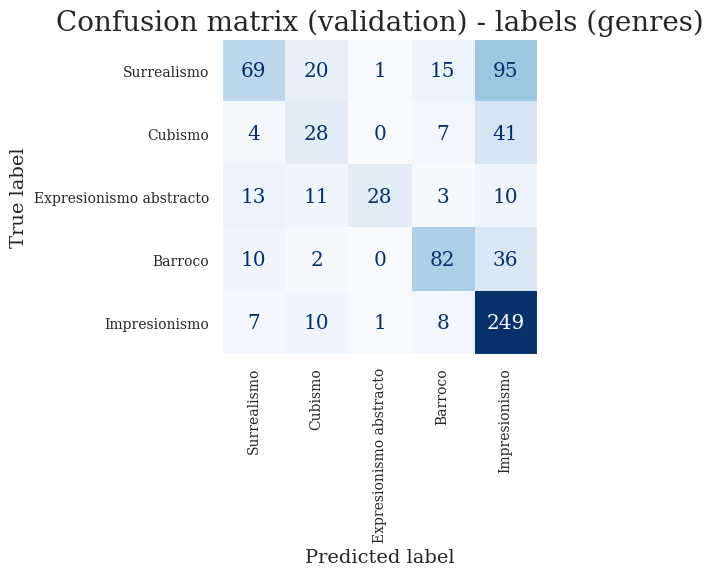

In [37]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_l_true, y_l_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - labels (genres)")
plt.tight_layout()
plt.grid(False)
plt.show()


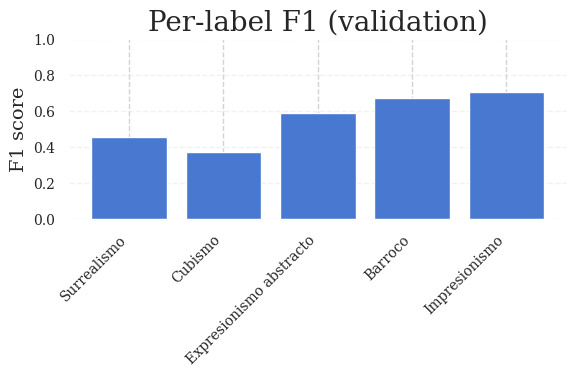

Surrealismo                   : F1 = 0.455
Cubismo                       : F1 = 0.371
Expresionismo abstracto       : F1 = 0.589
Barroco                       : F1 = 0.669
Impresionismo                 : F1 = 0.705


: 

In [ ]:
# === Cell 17: per-class F1 for labels ===

f1_per_label = f1_score(
    y_l_true,
    y_l_pred,
    average=None,
    labels=np.arange(NUM_LABELS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_LABELS), f1_per_label)
plt.xticks(range(NUM_LABELS), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(class_names, f1_per_label):
    print(f"{name:30s}: F1 = {f1_val:.3f}")
